# SP → RX Surrogate-Based Bayesian Optimization ScreeningThis notebook screens a large pool of candidate Ni–Cu catalyst structures using a Gaussian Process (GP) surrogate model. Instead of running expensive relaxed (RX) DFT calculations on every candidate, we use a cheap single-point (SP) adsorption energy as a proxy descriptor, train a GP on 50 structures where both SP and RX are known, and then predict RX (with uncertainty) for 10,000 unlabeled candidates.**Workflow overview:**```50 known structures (SP + RX)       ↓Confirm SP predicts RX (linear regression sanity check)       ↓Train a Gaussian Process: SP → RX       ↓Predict RX + uncertainty for 10,000 candidates       ↓Flag candidates outside the training range (extrapolation)       ↓Rank in-domain candidates by uncertainty       ↓Select the next batch of structures for DFT relaxation```This is a single round of active learning / uncertainty sampling. Once the selected candidates are relaxed via DFT, their true RX values would be added to the training set and the GP retrained for a subsequent round.

## Step 1 — Install packagesInstall the libraries needed for data handling, plotting, and Gaussian Process regression.

In [3]:
!pip install scikit-learn pandas openpyxl matplotlib

## Step 2 — Import libraries- `scikit-learn` provides the Gaussian Process regressor, kernels, cross-validation utilities, and the linear regression baseline.- `pandas` / `numpy` handle the tabular data.- `matplotlib` is used for the diagnostic plots below.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import (
    GaussianProcessRegressor
)

from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RBF,
    WhiteKernel
)

from sklearn.model_selection import (
    KFold,
    cross_val_predict
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

## Step 3 — Load the 50 known structuresThese are the ground-truth structures: for each one, we have both the cheap SP (single-point) adsorption energy and the expensive RX (relaxed) adsorption energy. This is the training set for the GP.

In [5]:
raw = pd.read_excel(
    "/content/dataset.xlsx",
    sheet_name="fresh_catalyst"
)

train = pd.DataFrame({
    "config_id": raw["config_id"],
    "SP": raw["ML+SP_Eads DFT"],
    "RX": raw["ML+RX_Eads DFT"]
})

print(train.head())
print(len(train))

   config_id        SP        RX
0          1 -5.509721 -5.876221
1          2 -5.836581 -6.369481
2          3 -5.919491 -6.348151
3          4 -5.445191 -5.863041
4          5 -5.813831 -6.361591
50


## Step 4 — Verify that SP is predictive of RXBefore trusting SP as a surrogate for RX, we sanity-check the relationship with a 5-fold cross-validated linear regression. A low mean absolute error (MAE) and high R² indicate SP carries real signal about RX, and justifies using it as the sole GP input feature below.

In [6]:
X = train[["SP"]]
y = train["RX"]

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

pred = cross_val_predict(
    LinearRegression(),
    X,
    y,
    cv=cv
)

print(
    "MAE =",
    mean_absolute_error(y, pred)
)

print(
    "R2 =",
    r2_score(y, pred)
)

MAE = 0.1050563302016689
R2 = 0.7808656645990191


### Visualize the SP–RX relationshipPlot the 50 known (SP, RX) pairs along with the linear fit, to visually confirm the trend before moving to the GP.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


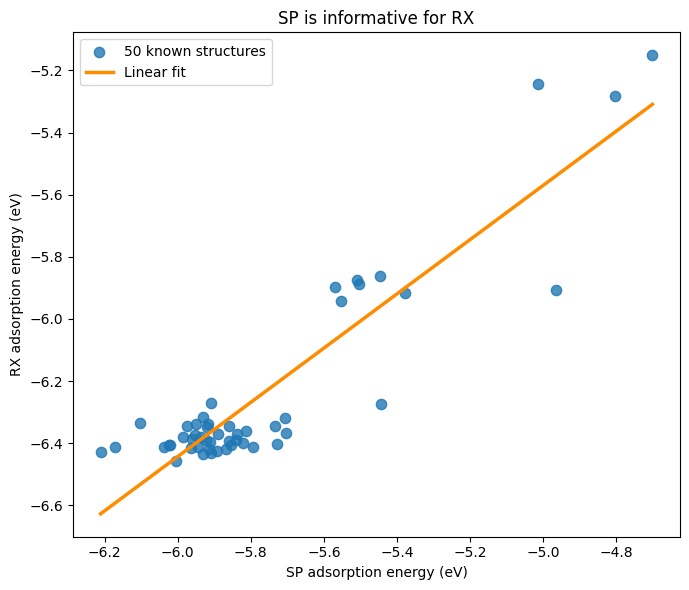

In [33]:
# Plot the 50 known SP and RX values with a linear fit

linear_model = LinearRegression()
linear_model.fit(X, y)

x_line = np.linspace(
    train["SP"].min(),
    train["SP"].max(),
    200
).reshape(-1, 1)

y_line = linear_model.predict(x_line)

plt.figure(figsize=(7, 6))

plt.scatter(
    train["SP"],
    train["RX"],
    s=55,
    alpha=0.8,
    label="50 known structures"
)

plt.plot(
    x_line,
    y_line,
    color="darkorange",
    linewidth=2.5,
    label="Linear fit"
)

plt.xlabel("SP adsorption energy (eV)")
plt.ylabel("RX adsorption energy (eV)")
plt.title("SP is informative for RX")
plt.legend()
plt.tight_layout()
plt.show()

## Step 5 — Train the Gaussian Process (SP → RX)We standardize the SP values, then fit a GP with an RBF kernel (captures the smooth trend) plus a White kernel (captures observation noise). The GP gives us both a predicted RX value and an uncertainty (standard deviation) for any new SP input — the uncertainty is what later drives candidate selection.

In [7]:
X_train = train[["SP"]].values
y_train = train["RX"].values

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(
    X_train
)

kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel()
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=0
)

gp.fit(
    X_train_scaled,
    y_train
)

print(gp.kernel_)

2.24**2 * RBF(length_scale=2.9) + WhiteKernel(noise_level=0.145)


## Step 6 — Load the candidate pool (10,000 structures)This is the large pool of candidates we want to screen. Unlike the 50 training structures, these only have the cheap SP value computed (no RX yet) — the whole point of the surrogate model is to avoid running RX on all 10,000 of them.

In [15]:
pool = pd.read_excel(
    "/content/dataset10000.xlsx",
    sheet_name="fresh_catalyst",
    header=1
)

pool.columns = (
    pool.columns
    .astype(str)
    .str.strip()
)

pool = pool.rename(
    columns={
        "EadsML+SP": "SP"
    }
)

print("Pool size:", len(pool))

print(
    pool[
        [
            "config_id",
            "SP"
        ]
    ].head()
)

Pool size: 10000
   config_id    SP
0          1 -5.63
1          2 -5.80
2          3 -5.92
3          4 -5.09
4          5 -5.52


## Step 7 — Clean the SP columnCoerce SP to numeric and drop any rows with missing or malformed SP values, so the GP only sees valid inputs.

In [16]:
pool["SP"] = pd.to_numeric(
    pool["SP"],
    errors="coerce"
)

print(
    "Missing SP values:",
    pool["SP"].isna().sum()
)

pool = pool.dropna(
    subset=["SP"]
)
pool = pool.copy()

print(
    "Final candidate count:",
    len(pool)
)

print(
    "Rows remaining:",
    len(pool)
)

Missing SP values: 0
Final candidate count: 10000
Rows remaining: 10000


## Step 8 — Predict RX and uncertainty for the full poolApply the trained GP to every candidate's SP value. This produces two new columns: `pred_RX` (the GP's best estimate of the relaxed adsorption energy) and `pred_std` (the GP's uncertainty in that estimate).

In [11]:
X_pool = pool[["SP"]].values

X_pool_scaled = x_scaler.transform(
    X_pool
)

pred_rx, pred_std = gp.predict(
    X_pool_scaled,
    return_std=True
)

pool["pred_RX"] = pred_rx
pool["pred_std"] = pred_std

pool.head()

,config_id,placement_successful,initial_site,final_site,site_changed,site_change_description,adsorption_site,composition,ni_atoms,cu_atoms,...,gas_phase_energy,adsorption_energy,optimization_steps,max_force,avg_binding_distance,n_surface_neighbors,structure_file,SP,pred_RX,pred_std
0,1,True,bridge,hollow,True,bridge → hollow,bridge,Ni67Cu13,67,13,...,-22.883561,-5.978797,49,0.030037,1.903064,3,structure_1_optimized_bridge.xyz,-5.63,-6.180217,0.120999
1,2,True,hollow,hollow,False,Remained hollow,hollow,Ni67Cu13,67,13,...,-22.883561,-6.126713,42,0.031935,1.858876,3,structure_2_optimized_hollow.xyz,-5.80,-6.316855,0.119567
2,3,True,ontop,hollow,True,ontop → hollow,ontop,Ni67Cu13,67,13,...,-22.883561,-6.730484,46,0.040993,1.861097,3,structure_3_optimized_ontop.xyz,-5.92,-6.383477,0.119233
3,4,True,hollow,hollow,False,Remained hollow,hollow,Ni67Cu13,67,13,...,-22.883561,-6.026860,42,0.036207,1.901142,3,structure_4_optimized_hollow.xyz,-5.09,-5.584261,0.127877
4,5,True,hollow,hollow,False,Remained hollow,hollow,Ni67Cu13,67,13,...,-22.883561,-5.795819,38,0.030636,1.909362,3,structure_5_optimized_hollow.xyz,-5.52,-6.070445,0.122336


## Step 9 — Visualize the candidate poolPlot every candidate's predicted RX against its SP, colored by GP uncertainty, with the 50 training points overlaid in red. Regions far from the training data (in SP space) should show visibly higher uncertainty — this is the extrapolation signal we use to flag risky predictions in the next step.

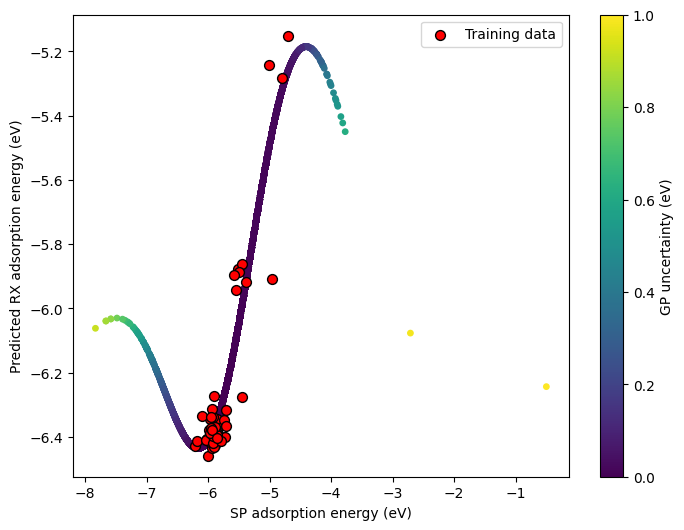

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    pool["SP"],
    pool["pred_RX"],
    c=pool["pred_std"],
    cmap="viridis",
    s=15
)

plt.scatter(
    train["SP"],
    train["RX"],
    color="red",
    edgecolor="black",
    s=50,
    label="Training data"
)

plt.colorbar(
    label="GP uncertainty (eV)"
)

plt.xlabel("SP adsorption energy (eV)")
plt.ylabel("Predicted RX adsorption energy (eV)")
plt.legend()

plt.show()

### Compare the training range to the candidate pool's SP rangeCheck how far the candidate pool's SP values extend beyond the range the GP was actually trained on.

In [31]:
print(train["SP"].min())
print(train["SP"].max())

print(pool["SP"].min())
print(pool["SP"].max())

-6.211011000000031
-4.701150999999971
-7.83
-0.5


### Inspect candidates flagged as outside the training range`outside_training_range` is a precomputed flag (from the dataset) marking candidates whose SP falls outside the 50-structure training range. For these, the GP is extrapolating rather than interpolating, so its predictions are less trustworthy — we exclude them from the ranked selection below and inspect them separately.

In [26]:
pool.loc[
    pool["outside_training_range"],
    [
        "config_id",
        "SP",
        "pred_RX",
        "pred_std",
        "structure_file"
    ]
].sort_values("SP")

,config_id,SP,pred_RX,pred_std,structure_file
8927,8928,-7.83,-6.062142,0.651718,structure_8928_optimized_bridge.xyz
8416,8417,-7.66,-6.039396,0.620720,structure_8417_optimized_hollow.xyz
7770,7771,-7.66,-6.039396,0.620720,structure_7771_optimized_ontop.xyz
7087,7088,-7.58,-6.033021,0.602112,structure_7088_optimized_hollow.xyz
8234,8235,-7.58,-6.033021,0.602112,structure_8235_optimized_bridge.xyz
...,...,...,...,...,...
7041,7042,-3.84,-5.403121,0.450849,structure_7042_optimized_hollow.xyz
7086,7087,-3.81,-5.422974,0.463406,structure_7087_optimized_ontop.xyz
7418,7419,-3.77,-5.450064,0.479741,structure_7419_optimized_hollow.xyz
121,122,-2.71,-6.077066,0.690613,structure_122_optimized_ontop.xyz


## Step 10 — Rank candidates for the next DFT batchThis is the active-learning / Bayesian optimization step: we use the GP's predictions to decide which of the 10,000 candidates are worth spending DFT time on next.**Current strategy: uncertainty sampling.** Candidates are ranked purely by `pred_std` (highest uncertainty first), restricted to those inside the training range. This targets the candidates the GP is *least* confident about, which is a good strategy for improving the model broadly, but does not by itself optimize toward the lowest-energy (best) structures — that would require an acquisition function such as Expected Improvement or Upper Confidence Bound layered on top of `pred_RX` and `pred_std` together.

In [20]:
# create predictions

X_pool = pool[["SP"]].values

X_pool_scaled = x_scaler.transform(
    X_pool
)

pred_rx, pred_std = gp.predict(
    X_pool_scaled,
    return_std=True
)

pool["pred_RX"] = pred_rx
pool["pred_std"] = pred_std

print(pool.columns.tolist())

['config_id', 'placement_successful', 'initial_site', 'final_site', 'site_changed', 'site_change_description', 'adsorption_site', 'composition', 'ni_atoms', 'cu_atoms', 'constraints_passed', 'dissociation_check', 'desorption_check', 'surface_mismatch_check', 'total_energy', 'clean_slab_energy', 'gas_phase_energy', 'adsorption_energy', 'optimization_steps', 'max_force', 'avg_binding_distance', 'n_surface_neighbors', 'structure_file', 'SP', 'pred_RX', 'pred_std']


### Select the top 20 candidates by uncertainty (in-domain only)Exclude structures already in the training set, exclude out-of-range candidates, then sort the remainder by `pred_std` and take the top 20. These are the structures proposed for the next round of RX relaxations. In a full iterative loop, their true RX values would then be folded back into the training set and the GP retrained.

In [34]:
# ==========================================
# BO ranking INSIDE training rangeUncertain prediction
# → run RX
# → obtain true RX
# → add result to training set
# → retrain GP
# → uncertainty should decrease in that SP region
# ==========================================

candidate_pool = pool[
    (
        ~pool["config_id"].isin(train["config_id"])
    )
    &
    (
        pool["outside_training_range"] == False
    )
].copy()

top20 = (
    candidate_pool
    .sort_values(
        by="pred_std",
        ascending=False
    )
    .head(20)
)

top20[
    [
        "config_id",
        "SP",
        "pred_RX",
        "pred_std",
        "structure_file"
    ]
]

,config_id,SP,pred_RX,pred_std,structure_file
8811,8812,-4.71,-5.266740,0.141310,structure_8812_optimized_bridge.xyz
7522,7523,-4.71,-5.266740,0.141310,structure_7523_optimized_bridge.xyz
6122,6123,-4.71,-5.266740,0.141310,structure_6123_optimized_hollow.xyz
1092,1093,-4.71,-5.266740,0.141310,structure_1093_optimized_ontop.xyz
3806,3807,-4.71,-5.266740,0.141310,structure_3807_optimized_hollow.xyz
7333,7334,-4.71,-5.266740,0.141310,structure_7334_optimized_ontop.xyz
9210,9211,-4.71,-5.266740,0.141310,structure_9211_optimized_ontop.xyz
54,55,-4.71,-5.266740,0.141310,structure_55_optimized_ontop.xyz
1628,1629,-4.71,-5.266740,0.141310,structure_1629_optimized_ontop.xyz
7749,7750,-4.72,-5.272235,0.140224,structure_7750_optimized_hollow.xyz


### Inspect the out-of-domain candidates separatelyThese candidates fall outside the SP range the GP was trained on. Their predicted RX values (and the associated high `pred_std`) should be treated as extrapolation, not reliable estimates — useful to know about, but not used for the ranked selection above.

In [35]:
# Out-of-domain candidates for exploration For these candidates, the GP is extrapolating.
# Their predicted RX values near −6 eV are not reliable estimates.
#  The high pred_std, approximately 0.53 to 0.70 eV in the displayed table, is the warning

outside_pool = pool[
    pool["outside_training_range"]
].copy()

outside_pool[
    [
        "config_id",
        "SP",
        "pred_RX",
        "pred_std",
        "structure_file"
    ]
].sort_values(
    "pred_std",
    ascending=False
).head(10)

,config_id,SP,pred_RX,pred_std,structure_file
2896,2897,-0.50,-6.243764,0.700834,structure_2897_optimized_bridge.xyz
121,122,-2.71,-6.077066,0.690613,structure_122_optimized_ontop.xyz
8927,8928,-7.83,-6.062142,0.651718,structure_8928_optimized_bridge.xyz
7770,7771,-7.66,-6.039396,0.620720,structure_7771_optimized_ontop.xyz
8416,8417,-7.66,-6.039396,0.620720,structure_8417_optimized_hollow.xyz
8234,8235,-7.58,-6.033021,0.602112,structure_8235_optimized_bridge.xyz
7087,7088,-7.58,-6.033021,0.602112,structure_7088_optimized_hollow.xyz
6127,6128,-7.48,-6.030287,0.575022,structure_6128_optimized_hollow.xyz
8832,8833,-7.39,-6.033675,0.547003,structure_8833_optimized_hollow.xyz
7876,7877,-7.35,-6.037149,0.533478,structure_7877_optimized_bridge.xyz


## Step 11 — Save the selected candidatesExport the top 20 candidates (config ID, SP, predicted RX, uncertainty, and structure file name) to an Excel file, ready to hand off for DFT relaxation.

In [38]:
top20[
    [
        "config_id",
        "SP",
        "pred_RX",
        "pred_std",
        "structure_file"
    ]
].head(20).to_excel(
    "/content/top20_BO_candidates.xlsx",
    index=False
)

## Next steps1. Run DFT relaxations on the 20 selected structures to obtain their true RX values.2. Add these 20 (SP, RX) pairs to the training set.3. Retrain the GP on the expanded training set — uncertainty in that region of SP space should shrink.4. Repeat for subsequent rounds, and/or replace uncertainty sampling with an acquisition function (EI/UCB) if the goal shifts from model-improvement to finding the lowest-energy structures directly.